In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

from util.Processing import td_nnlsr_deconvolve

from sklearn.covariance import EllipticEnvelope

In [16]:
def load_strange_xtr(file):
    traces = []
    
    with open(file, 'r', encoding='UTF-8') as file:
        while line := file.readline():
            line = line.rstrip()
            if 'eRC' not in line:
                continue
            line = '{' + line.split('{')[-1]
            dict_ = eval(line)
            traces.append(np.array(dict_['pulse']))
    return traces
        
    

eRC4177nai_xtr_220522_182751.xtr
28706
2108
2108
2108
2108
eRC4181lpl_xtr_220522_182751.xtr
28706
2108
2108
2108
2108


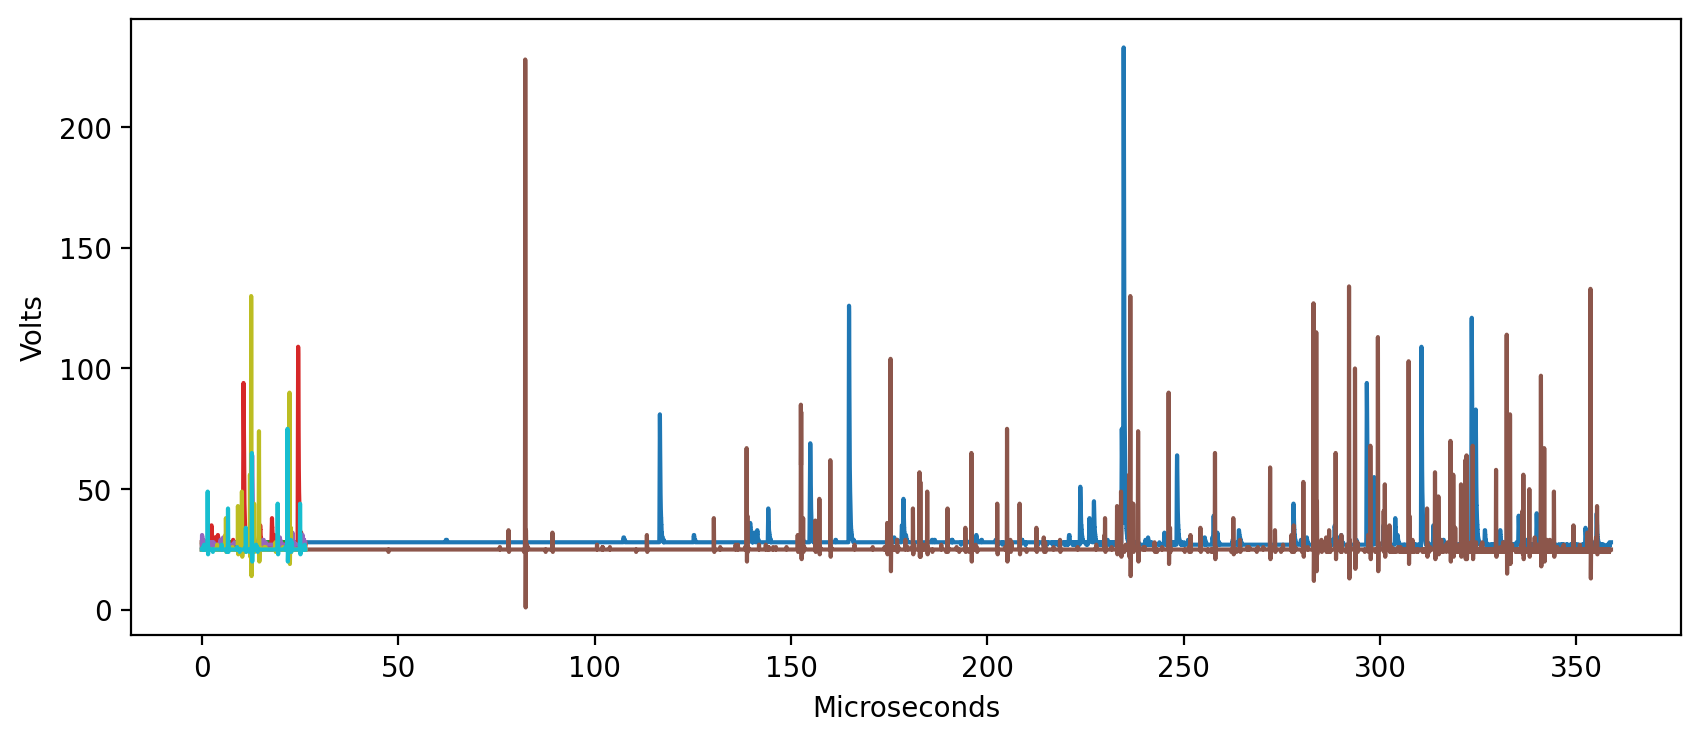

In [17]:
files = ['eRC4177nai_xtr_220522_182751.xtr', 'eRC4181lpl_xtr_220522_182751.xtr']

fs = 80E6
dt = 1 / fs

MICRO = 1E6

fig, axes = plt.subplots(1,1,figsize=(10,4), dpi=200)
axes.set_xlabel('Microseconds')
axes.set_ylabel('Volts')

long_traces = []

for file in files:
    print(file)
    traces = load_strange_xtr(file)
    
    for trace in traces:
        print(len(trace))
        time = dt * np.arange(trace.size)
        axes.plot(time*MICRO, trace)
        
        if trace.size > 10000:
            long_traces.append(trace)
        
# t = 80
# axes.set_xlim(t,t+10)
# # axes.set_ylim(0, 150)

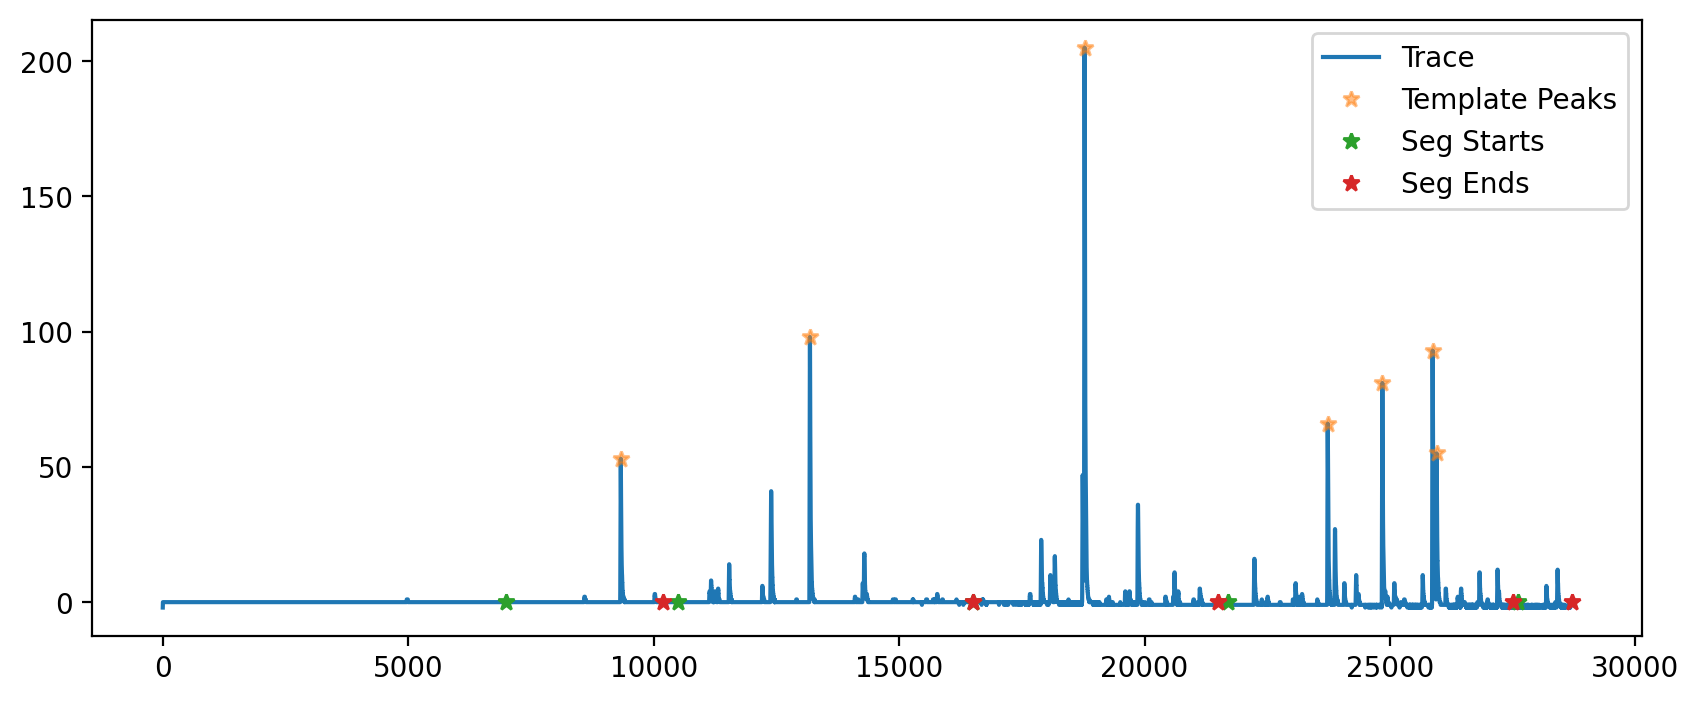

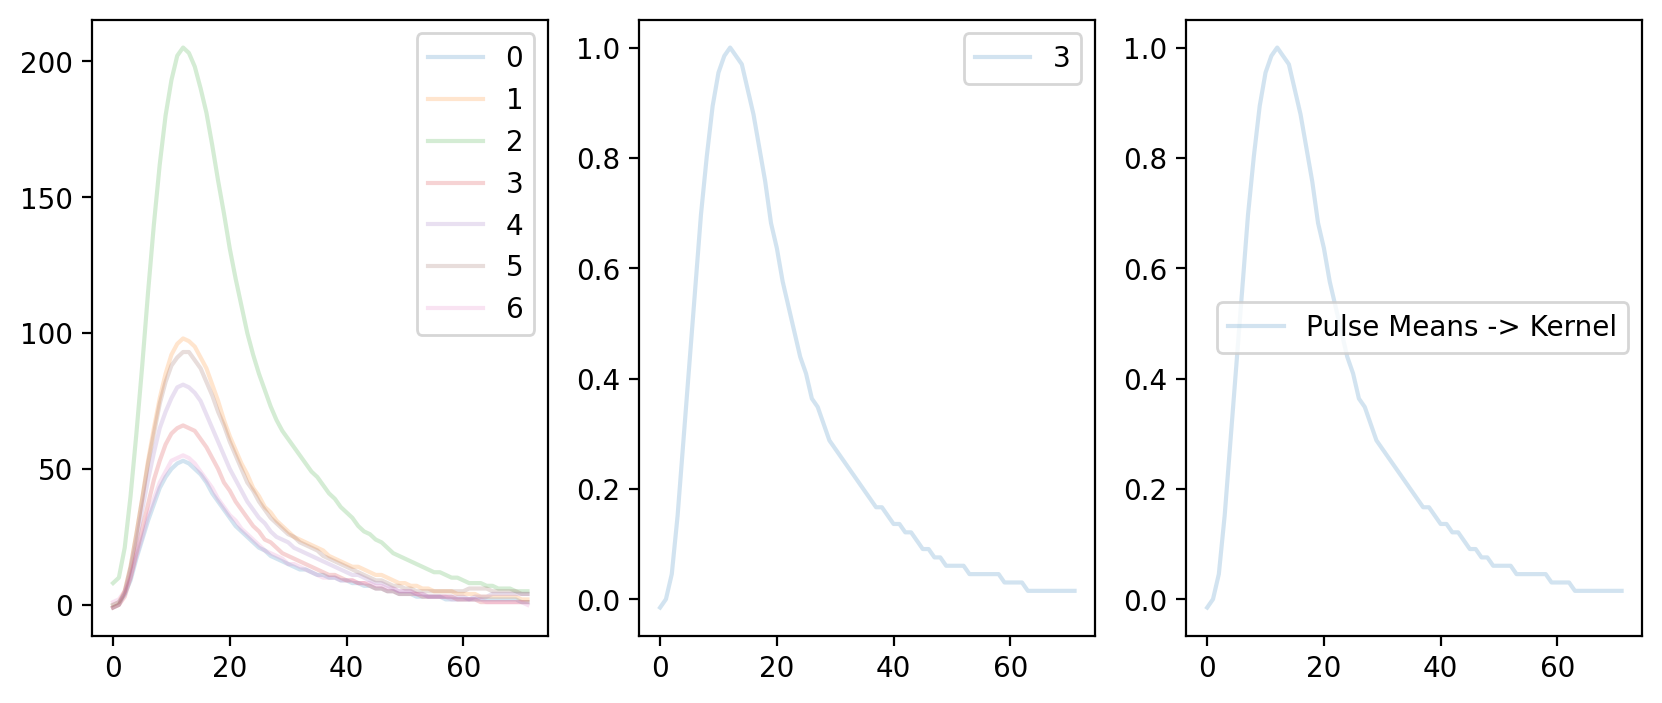

In [18]:
trace = long_traces[0]
baseline,_ = scipy.stats.mode(trace, keepdims=False)
trace = trace - baseline
index = np.arange(trace.size)
microseconds = dt * index * MICRO

limit1 = 50
segment_bounds = [
    (7000, 10200),
    (10500, 16500),
    (16500, 21500),
    (21700, 27500),
    (27600, trace.size-1)
    ]

argpeaks, _ = scipy.signal.find_peaks(trace)
argpeaks = argpeaks[trace[argpeaks] > limit1]

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
axis.plot(index, trace, label='Trace')
axis.plot(index[argpeaks], trace[argpeaks], '*', alpha=.5, label='Template Peaks')

seg_bounds_npy = np.array(segment_bounds)
axis.plot(seg_bounds_npy[:,0], np.zeros_like(seg_bounds_npy[:,0]), '*', alpha=1, label='Seg Starts')
axis.plot(seg_bounds_npy[:,1], np.zeros_like(seg_bounds_npy[:,1]), '*', alpha=1, label='Seg Ends')
axis.legend()

skip_peaks = [0,1,2,4,5,6]
template_pulses = []
fig, axes = plt.subplots(1,3,figsize=(10,4), dpi=200)
for i, argpeak in enumerate(argpeaks.tolist()):
    try:
        pulse = trace[argpeak - 12 : argpeak + 60]
        axes[0].plot(pulse, alpha=.2, label=i)
        
        if i in skip_peaks:
            continue
        
        pulse = pulse / np.max(pulse)
        template_pulses.append(pulse)
        axes[1].plot(pulse, alpha=.2, label=i)
    except:
        pass
    
kernel = np.mean(np.stack(template_pulses), axis=0)

if argpeaks.size < 100:
    axes[0].legend()
    axes[1].legend()

axes[2].plot(kernel, alpha=.2, label='Pulse Means -> Kernel')
axes[2].legend()

In [19]:
deconv = np.zeros_like(trace)
for lower, upper in segment_bounds:
    subtrace = trace[lower:upper+1]

    sub_deconv = td_nnlsr_deconvolve(subtrace, kernel)
    
    deconv[lower:upper+1] = sub_deconv

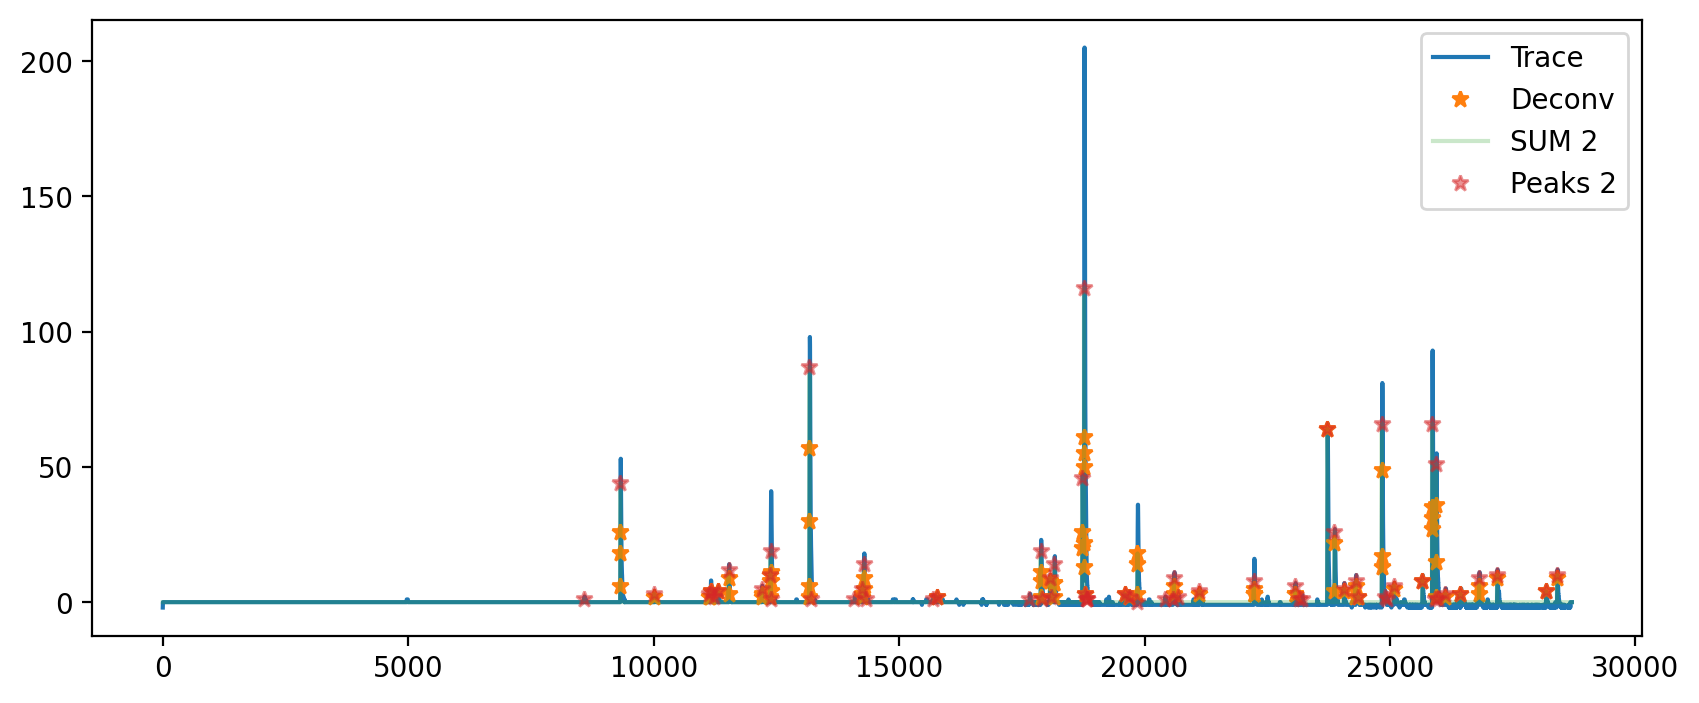

In [20]:
thresh = 1
nsum = 9

deconv_thresh_index = index[deconv > thresh]

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
axis.plot(index, trace, label = 'Trace')
axis.plot(index[deconv_thresh_index], deconv[deconv_thresh_index], label = 'Deconv', marker='*', linestyle='')

for i in range(2,3):
# for i in range(9,10):
    convsum = np.convolve(deconv, np.ones(i), mode='same')
    smoothed = scipy.ndimage.gaussian_filter1d(convsum, sigma=3)
    convsum_peaks,_ = scipy.signal.find_peaks(smoothed, distance=i)
    axis.plot(index, convsum, label = 'SUM {}'.format(i), alpha=.25)
    axis.plot(index[convsum_peaks], convsum[convsum_peaks],
              marker='*', linestyle='', label = 'Peaks {}'.format(i), alpha=.5)

# axis.set_xlim(12000,13000)
axis.legend()    

# axis.set_xlim(0, 30000)
# axis.set_xlim(9000, 12000)
# axis.set_xlim(11000, 14000)
# axis.set_xlim(17500, 19000)
# axis.set_xlim(19500, 24000)
# axis.set_xlim(22000, 22500)
# axis.set_xlim(19500, 20000)
# axis.set_xlim(22000, 28000)
# axis.set_xlim(23500, 26500)

# axis.set_ylim(-5,50)

convsum = np.convolve(deconv, np.ones(nsum), mode='same')
smoothed = scipy.ndimage.gaussian_filter1d(convsum, sigma=3)
convsum_peaks,_ = scipy.signal.find_peaks(smoothed,distance=nsum)

fig, axis = plt.subplots(1,1,figsize=(80,4), dpi=400)
axis.plot(microseconds, trace, label = 'Trace', linewidth=1)
# axis.plot(microseconds, convsum, label = 'CONVSUM', alpha=.25)
axis.plot(microseconds[convsum_peaks], convsum[convsum_peaks],
          marker='*', linestyle='', label = 'Peaks', alpha=.75)

axis.set_xlabel('Microseconds')
axis.set_ylabel('Volts')
axis.legend()
plt.savefig('NaI_Deconvolution_long')
plt.close()

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=400)
axis.plot(microseconds, trace, label = 'Trace', linewidth=1)
# axis.plot(microseconds, convsum, label = 'CONVSUM', alpha=.25)
axis.plot(microseconds[convsum_peaks], convsum[convsum_peaks],
          marker='*', linestyle='', label = 'Peaks', alpha=.75)

axis.set_xlabel('Microseconds')
axis.set_ylabel('Volts')
axis.legend()
plt.savefig('NaI_Deconvolution')
plt.close()


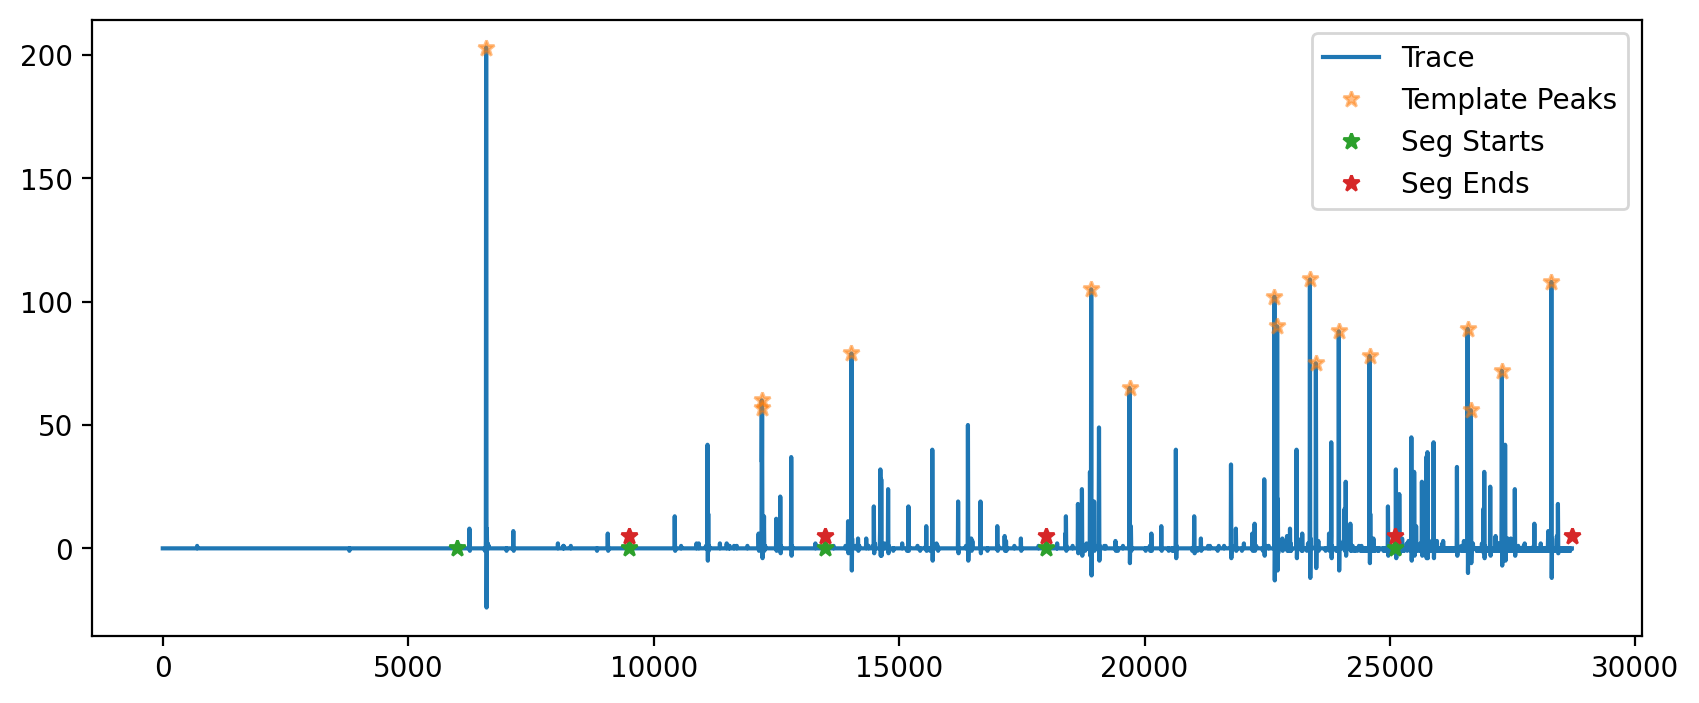

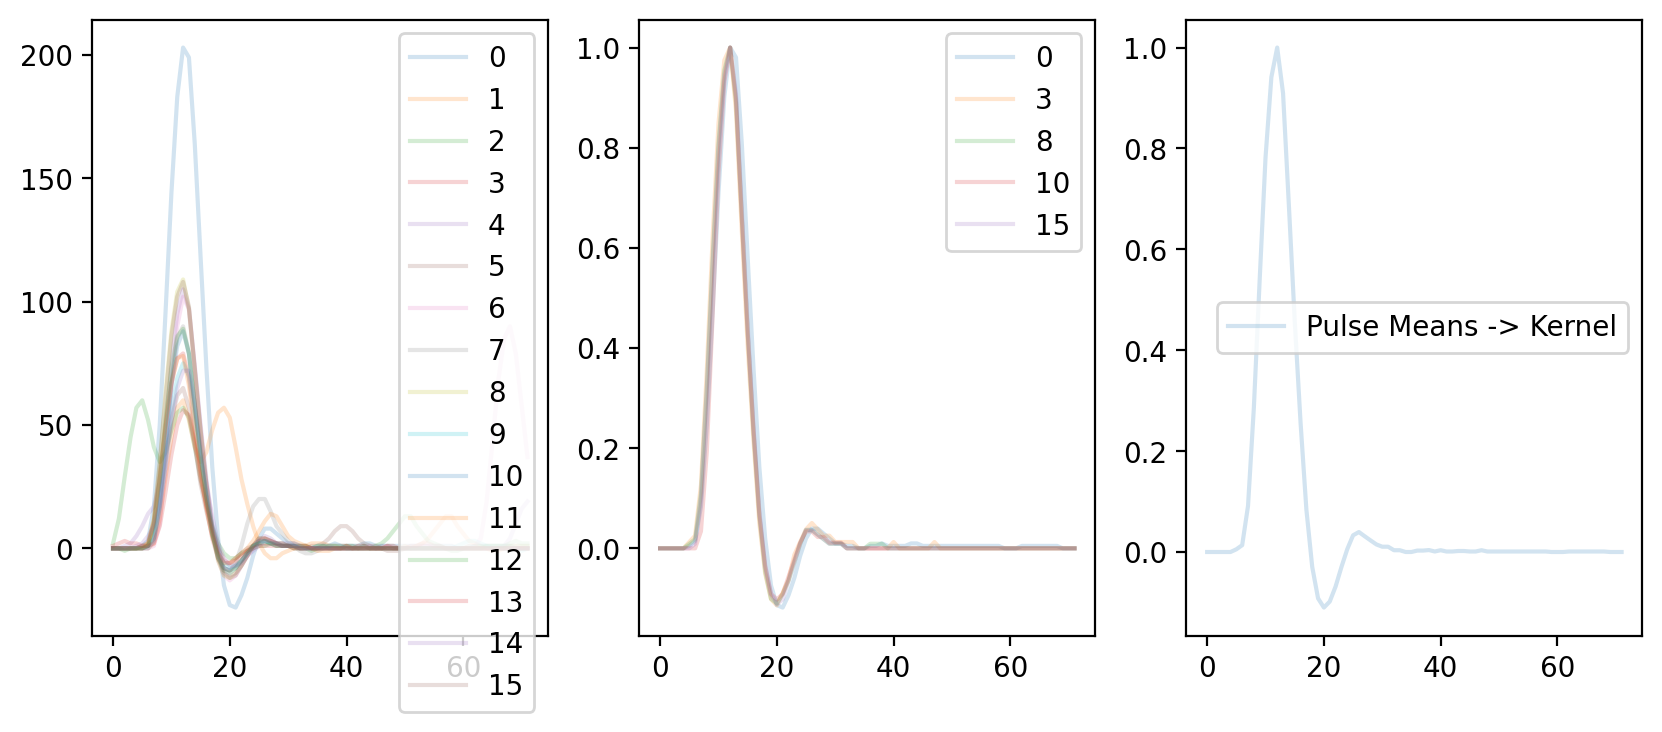

In [7]:
trace = long_traces[1]
baseline,_ = scipy.stats.mode(trace, keepdims=False)
trace = trace - baseline
limit1 = 50

segment_bounds = [
    (6000, 9500),
    (9500, 13500),
    (13500, 18000),
    (18000, 25100),
    (25100, trace.size-1)
    ]

index = np.arange(trace.size)
argpeaks, _ = scipy.signal.find_peaks(trace)
argpeaks = argpeaks[trace[argpeaks] > limit1]

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
axis.plot(index, trace, label='Trace')
axis.plot(index[argpeaks], trace[argpeaks], '*', alpha=.5, label='Template Peaks')

seg_bounds_npy = np.array(segment_bounds)
axis.plot(seg_bounds_npy[:,0], np.zeros_like(seg_bounds_npy[:,0]), '*', alpha=1, label='Seg Starts')
axis.plot(seg_bounds_npy[:,1], 5 * np.ones_like(seg_bounds_npy[:,1]), '*', alpha=1, label='Seg Ends')
axis.legend()

# axis.set_xlim(0, 30000)
# axis.set_xlim(10000, 15000)
# axis.set_xlim(20000, 25000)
# axis.set_xlim(25000, 26000)
# axis.set_xlim(25000, 30000)

skip_peaks  = [1,2,4,5,6,7,9,11,12,13,14]
template_pulses = []
fig, axes = plt.subplots(1,3,figsize=(10,4), dpi=200)
for i, argpeak in enumerate(argpeaks.tolist()):
    try:
        pulse = trace[argpeak - 12 : argpeak + 60]
        axes[0].plot(pulse, alpha=.2, label=i)

        if i in skip_peaks:
            continue

        pulse = pulse / np.max(pulse)
        template_pulses.append(pulse)
        axes[1].plot(pulse, alpha=.2, label=i)
    except:
        pass

kernel = np.mean(np.stack(template_pulses), axis=0)

if argpeaks.size < 100:
    axes[0].legend()
    axes[1].legend()

axes[2].plot(kernel, alpha=.2, label='Pulse Means -> Kernel')
axes[2].legend()

In [8]:
deconv = np.zeros_like(trace)
for lower, upper in segment_bounds:
    subtrace = trace[lower:upper+1]

    print(subtrace.size)

    sub_deconv = td_nnlsr_deconvolve(subtrace, kernel)
    deconv[lower:upper+1] = sub_deconv

3501
4001
4501
7101
3606


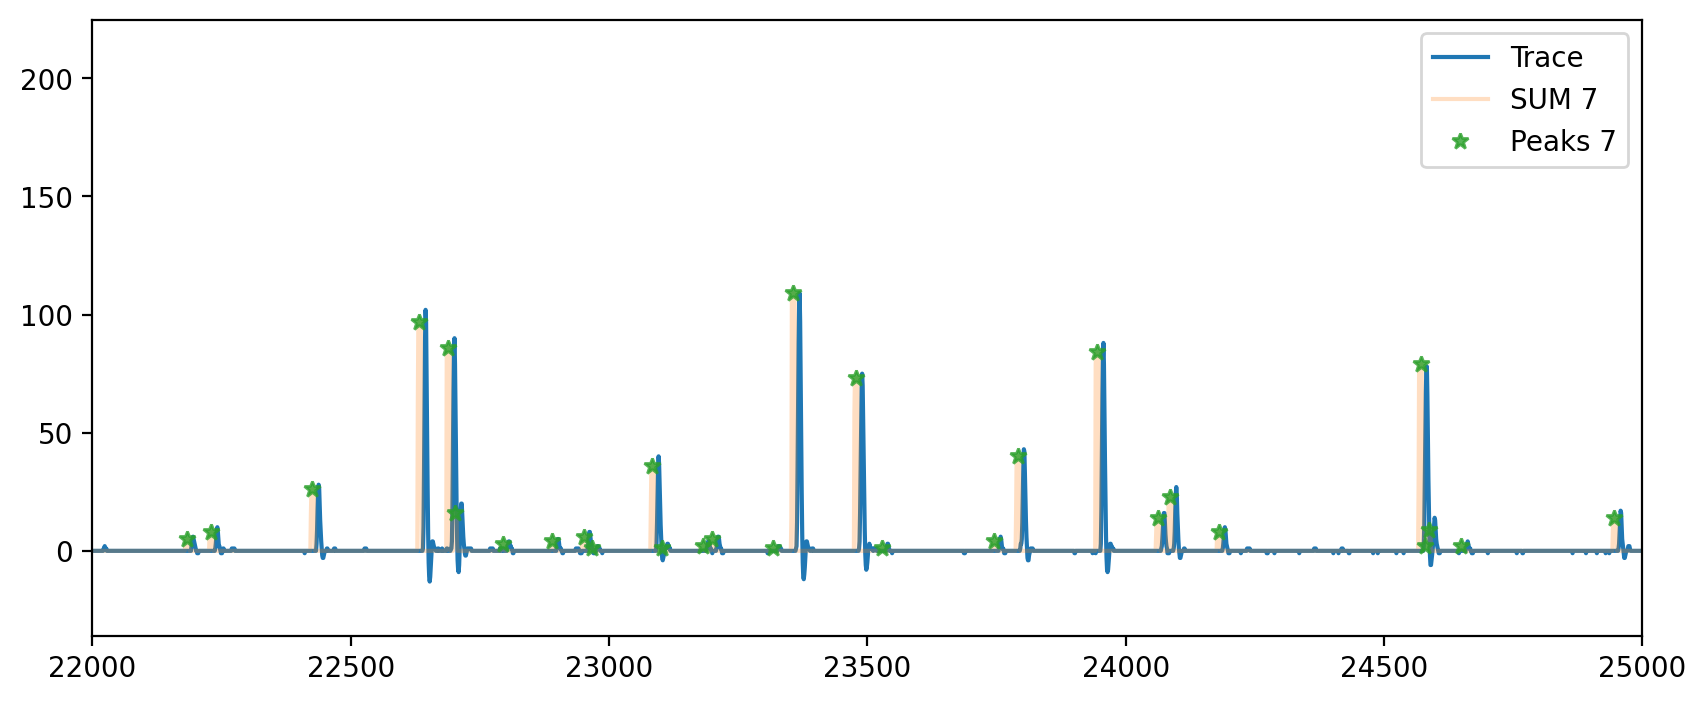

In [14]:
thresh = 1
nsum = 7
deconv_thresh_index = index[deconv > thresh]

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
axis.plot(index, trace, label = 'Trace')
# axis.plot(index[deconv_thresh_index], deconv[deconv_thresh_index], label = 'Deconv', marker='*', linestyle='')

for i in range(7,8):
# for i in range(2,8):
    convsum = np.convolve(deconv, np.ones(i), mode='same')
    smoothed = scipy.ndimage.gaussian_filter1d(convsum, sigma=1)
    convsum_peaks,_ = scipy.signal.find_peaks(smoothed, distance=i)
    axis.plot(index, convsum, label = 'SUM {}'.format(i), alpha=.25)
    axis.plot(index[convsum_peaks], convsum[convsum_peaks],
              marker='*', linestyle='', label = 'Peaks {}'.format(i), alpha=.8)
    
# axis.set_xlim(20000,23000)
axis.legend()

# axis.set_xlim(0, 30000)
# axis.set_xlim(6500, 7000)
# axis.set_xlim(9000, 12000)
# axis.set_xlim(11000, 14000)
# axis.set_xlim(12000, 12500)
# axis.set_xlim(17500, 19000)
axis.set_xlim(22000, 25000)
# axis.set_xlim(23500, 26500)


convsum = np.convolve(deconv, np.ones(nsum), mode='same')
# smoothed = scipy.ndimage.gaussian_filter1d(convsum, sigma=3)
smoothed = convsum
convsum_peaks,_ = scipy.signal.find_peaks(smoothed,distance=nsum)

fig, axis = plt.subplots(1,1,figsize=(80,4), dpi=400)
axis.plot(microseconds, trace, label = 'Trace', linewidth=1)
# axis.plot(microseconds, convsum, label = 'CONVSUM', alpha=.25)
axis.plot(microseconds[convsum_peaks], convsum[convsum_peaks],
          marker='*', linestyle='', label = 'Peaks', alpha=.75)

axis.set_xlabel('Microseconds')
axis.set_ylabel('Volts')
axis.legend()
plt.savefig('Plastic_Deconvolution_long')
plt.close()

fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=400)
axis.plot(microseconds, trace, label = 'Trace', linewidth=1)
# axis.plot(microseconds, convsum, label = 'CONVSUM', alpha=.25)
axis.plot(microseconds[convsum_peaks], convsum[convsum_peaks],
          marker='*', linestyle='', label = 'Peaks', alpha=.75)

axis.set_xlabel('Microseconds')
axis.set_ylabel('Volts')
axis.legend()
plt.savefig('Plastic_Deconvolution')
plt.close()

np.savetxt('eRC4181lpl_xtr_220522_182751.txt', np.stack((index[convsum_peaks].astype(int), convsum[convsum_peaks])), delimiter=',')

In [10]:
# #
# # Test Test Test
# #
# 
# thresh = 1
# nsum = 7
# deconv_thresh_index = index[deconv > thresh]
# 
# fig, axis = plt.subplots(1,1,figsize=(10,4), dpi=200)
# # axis.plot(index, trace, label = 'Trace')
# # axis.plot(index[deconv_thresh_index], deconv[deconv_thresh_index], label = 'Deconv', marker='*', linestyle='')
# 
# print(deconv.dtype)
# convsum = np.zeros(trace.size,dtype=np.double)
# for i in range(2,8):
#     convsum += np.convolve(deconv, np.ones(i), mode='same')
# 
# convsum /= deconv
# 
# axis.plot(index, trace, label = 'Trace')
# axis.plot(index[deconv_thresh_index], deconv[deconv_thresh_index], label = 'Deconv', marker='*', linestyle='')
# axis.plot(convsum, label='convsum')
# 
# axis.set_xlim(15000, 20000)
#     
#     
# # for i in range(7,8):
# # # for i in range(2,8):
# #     convsum = np.convolve(deconv, np.ones(i), mode='same')
# #     smoothed = scipy.ndimage.gaussian_filter1d(convsum, sigma=1)
# #     convsum_peaks,_ = scipy.signal.find_peaks(smoothed, distance=i)
# #     axis.plot(index, convsum, label = 'SUM {}'.format(i), alpha=.25)
# #     axis.plot(index[convsum_peaks], convsum[convsum_peaks],
# #               marker='*', linestyle='', label = 'Peaks {}'.format(i), alpha=.8)
#     
# # axis.set_xlim(23000,24000)
# axis.legend()